# ResNet-18 (Unfrozen Backbone)

**Objective**: Establish a stronger baseline by unfreezing the entire ResNet-18 backbone. This allows the model to fine-tune its pretrained ImageNet features to the specific textures and color distributions of dermatological lesions, rather than just training a linear classifier on top of fixed features.

**Architecture Changes**:
| Component | Previous iteration (Naive) | This iteration (Unfreeze) |
|---|---|---|
| Backbone | Frozen (FC only) | Unfrozen (All layers) |
| Optimizer scope | `model.fc.parameters()` | `model.parameters()` |
| Learning rate | `1e-3` | `1e-4` |
| Trainable params | ~513 | ~11.2M |
| Weight decay | 0 | 0 |
| L1 lambda | 0 | 0 |
| L2 lambda | 0 | 0 |
| Dropout | 0 | 0 |
| Epochs | 20 | 20 |

**Hypothesis**: Fine-tuning the backbone should significantly improve discriminative performance (AUC-ROC) and recall compared to the naive baseline. However, without regularization, the model is expected to overfit heavily on the training set given the relatively small size of HAM10000.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_resnet(num_classes=1, freeze_backbone=False).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0
dropout = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {dropout}')

Trainable params: 11,177,025 / 11,177,025
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.0


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/resnet_unfreeze_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 0.9114, Bal Acc: 0.7506, Recall: 0.8027, F2: 0.5537, AUC: 0.8246
  Val   | Loss: 0.9047, Bal Acc: 0.7544, Recall: 0.6822, F2: 0.5689, AUC: 0.8561
  -> Saved best model (val AUC: 0.8561)


Epoch [2/20]
  Train | Loss: 0.7892, Bal Acc: 0.7912, Recall: 0.8449, F2: 0.6057, AUC: 0.8679
  Val   | Loss: 0.8158, Bal Acc: 0.7717, Recall: 0.8347, F2: 0.5927, AUC: 0.8664
  -> Saved best model (val AUC: 0.8664)


Epoch [3/20]
  Train | Loss: 0.7491, Bal Acc: 0.7975, Recall: 0.8324, F2: 0.6158, AUC: 0.8837
  Val   | Loss: 0.7632, Bal Acc: 0.7749, Recall: 0.8093, F2: 0.5972, AUC: 0.8798
  -> Saved best model (val AUC: 0.8798)


Epoch [4/20]
  Train | Loss: 0.7292, Bal Acc: 0.8109, Recall: 0.8575, F2: 0.6333, AUC: 0.8906
  Val   | Loss: 0.7572, Bal Acc: 0.7766, Recall: 0.8475, F2: 0.5988, AUC: 0.8861
  -> Saved best model (val AUC: 0.8861)


Epoch [5/20]
  Train | Loss: 0.6965, Bal Acc: 0.8172, Recall: 0.8597, F2: 0.6428, AUC: 0.8986
  Val   | Loss: 0.8171, Bal Acc: 0.7928, Recall: 0.7712, F2: 0.6241, AUC: 0.8856


...

Epoch [16/20]
  Train | Loss: 0.5394, Bal Acc: 0.8694, Recall: 0.8997, F2: 0.7251, AUC: 0.9419
  Val   | Loss: 0.7352, Bal Acc: 0.8015, Recall: 0.7500, F2: 0.6395, AUC: 0.9090
  -> Saved best model (val AUC: 0.9090)


Epoch [17/20]
  Train | Loss: 0.5007, Bal Acc: 0.8742, Recall: 0.8940, F2: 0.7359, AUC: 0.9500
  Val   | Loss: 0.7716, Bal Acc: 0.7964, Recall: 0.8008, F2: 0.6279, AUC: 0.9006


Epoch [18/20]
  Train | Loss: 0.4951, Bal Acc: 0.8777, Recall: 0.9031, F2: 0.7402, AUC: 0.9500
  Val   | Loss: 0.8825, Bal Acc: 0.7950, Recall: 0.7500, F2: 0.6290, AUC: 0.8925


Epoch [19/20]
  Train | Loss: 0.4614, Bal Acc: 0.8951, Recall: 0.9202, F2: 0.7700, AUC: 0.9576
  Val   | Loss: 0.8349, Bal Acc: 0.8042, Recall: 0.7712, F2: 0.6422, AUC: 0.8939


Epoch [20/20]
  Train | Loss: 0.4215, Bal Acc: 0.9019, Recall: 0.9247, F2: 0.7828, AUC: 0.9630
  Val   | Loss: 0.8749, Bal Acc: 0.8047, Recall: 0.7924, F2: 0.6413, AUC: 0.9029


## Plot Train and Validation Curves

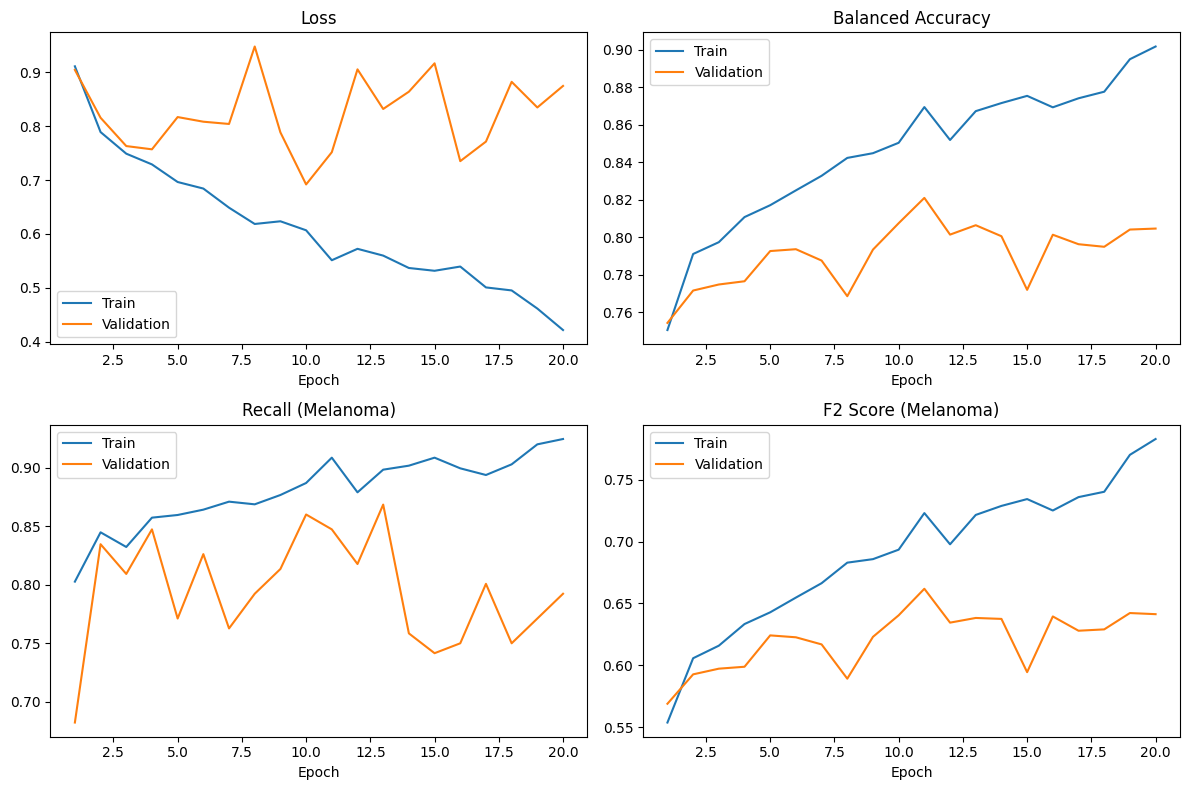

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet_unfreeze_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.31 | Val F2: 0.6573


## Test Set Evaluation

Threshold:          0.31
AUC-ROC:            0.9082
Balanced Accuracy:  0.8294
F2 Score:           0.6627

              precision    recall  f1-score   support

Non-Melanoma     0.9835    0.7582    0.8563      1340
    Melanoma     0.3222    0.9006    0.4746       171

    accuracy                         0.7743      1511
   macro avg     0.6529    0.8294    0.6654      1511
weighted avg     0.9087    0.7743    0.8131      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


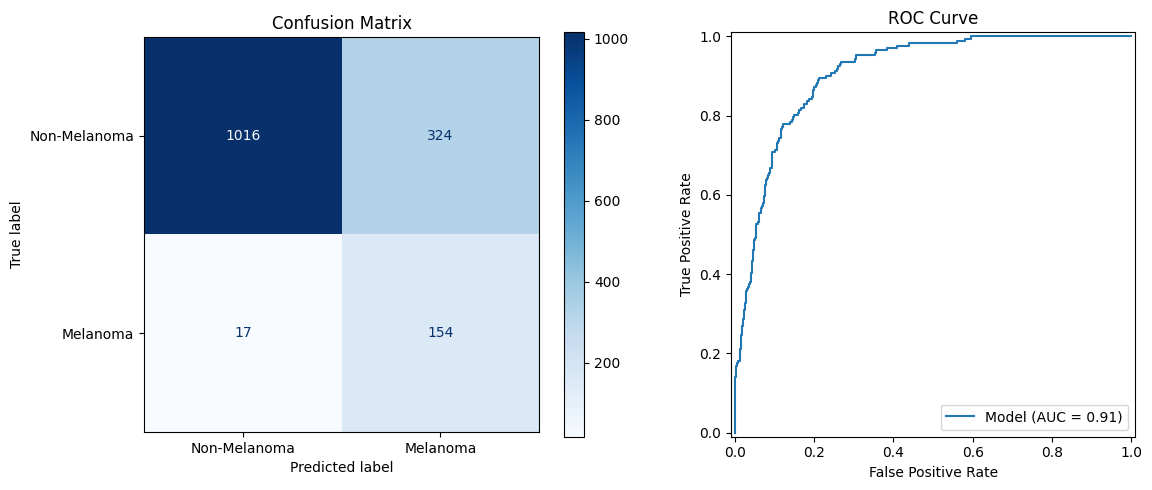

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)